<a href="https://colab.research.google.com/github/SilasDetering/SilasBA/blob/main/Silas_BA_Graphen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

# 1. Graph: RSSI for Distances

In [ ]:
# Datei hochladen
uploaded = files.upload()
file_name = next(iter(uploaded))

# Excel-Datei einlesen
df = pd.read_excel(file_name, header=None)
df = df.replace(',', '.', regex=True)

Saving messung1-rssionly.xlsx to messung1-rssionly.xlsx


Optimierte Parameter: n = 0.66, a = -49.53


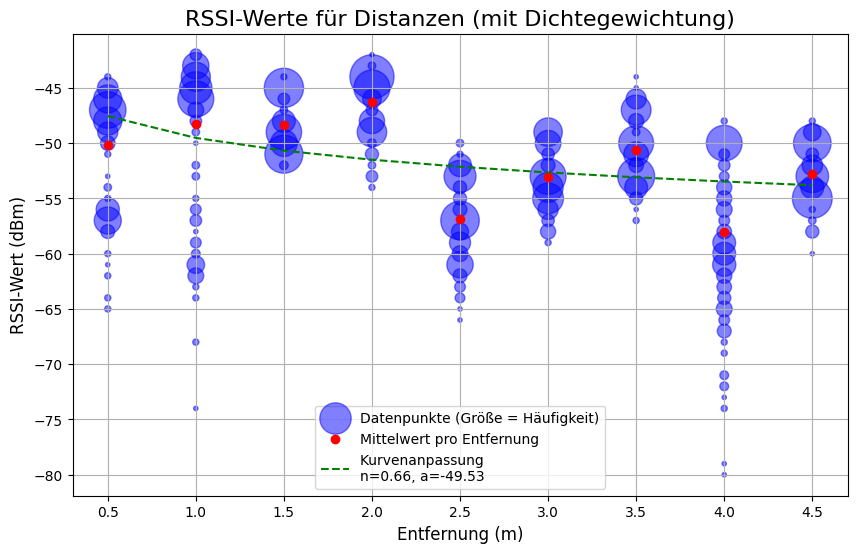

In [ ]:
# Die erste Zeile als Entfernungen verwenden
distances = df.iloc[0, :]

# Die restlichen Zeilen als RSSI-Werte
rssi_values = df.iloc[1:, :]

# Daten ins Long-Format umwandeln
df_long = rssi_values.melt(var_name='distance_index', value_name='rssi')
df_long['distance'] = distances[df_long['distance_index']].values
df_long = df_long.drop(columns=['distance_index']).dropna().reset_index(drop=True)

# Häufigkeit der Datenpunkte berechnen
point_counts = df_long.groupby(['distance', 'rssi']).size().reset_index(name='count')

# Mittelwert der RSSI-Werte für jede Entfernung berechnen
mean_rssi_per_distance = df_long.groupby('distance')['rssi'].mean()

# Modellfunktion definieren
def rssi_model(distance, n, a):
    return -10 * n * np.log10(distance) + a

# Curve-Fit durchführen
popt, pcov = curve_fit(rssi_model, mean_rssi_per_distance.index, mean_rssi_per_distance.values)

# Optimierte Parameter
n, a = popt
print(f"Optimierte Parameter: n = {n:.2f}, a = {a:.2f}")

# Fit-Daten berechnen
fitted_rssi = rssi_model(mean_rssi_per_distance.index, n, a)

# Scatterplot erstellen
plt.figure(figsize=(10, 6))

# Datenpunkte mit Größen entsprechend ihrer Häufigkeit plotten
plt.scatter(point_counts['distance'], point_counts['rssi'],
            s=point_counts['count'] * 10,  # Größe proportional zur Häufigkeit
            alpha=0.5,
            label='Datenpunkte (Größe = Häufigkeit)',
            color='blue')

# Mittelwert als Punkte für jede Entfernung zeichnen
plt.scatter(mean_rssi_per_distance.index, mean_rssi_per_distance.values,
            color='red', label='Mittelwert pro Entfernung', zorder=5)

# Angepasste Kurve hinzufügen
plt.plot(mean_rssi_per_distance.index, fitted_rssi,
         color='green', linestyle='--',
         label=f'Kurvenanpassung \nn={n:.2f}, a={a:.2f}')

# Titel und Achsenbeschriftungen hinzufügen
plt.title("RSSI-Werte für Distanzen (mit Dichtegewichtung)", fontsize=16)
plt.xlabel("Entfernung (m)", fontsize=12)
plt.ylabel("RSSI-Wert (dBm)", fontsize=12)

# Legende hinzufügen
plt.legend()

# Raster aktivieren
plt.grid(True)

# Plot anzeigen
plt.show()


# 1,5. Graph: RSSI for Distances with Hard Fluctuation Filter

Optimierte Parameter: n = 0.78, a = -49.85


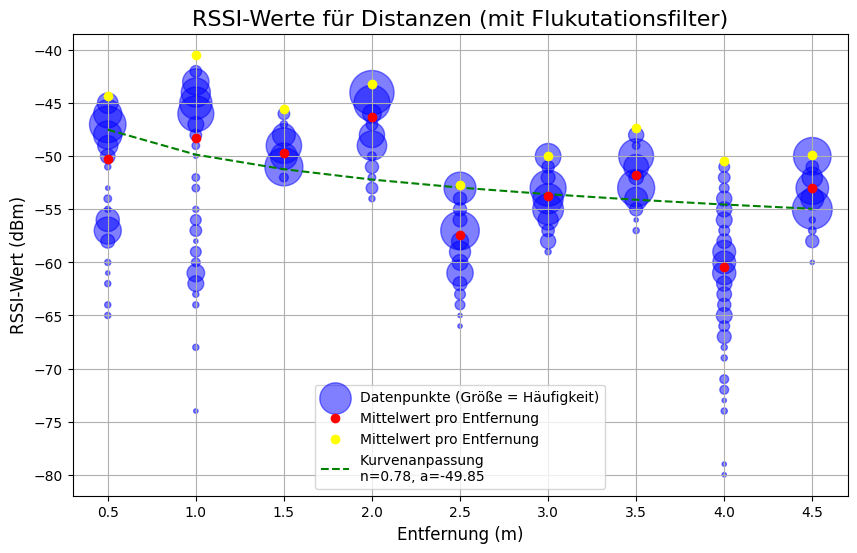

In [ ]:
# Die erste Zeile als Entfernungen verwenden
distances = df.iloc[0, :]

# Die restlichen Zeilen als RSSI-Werte
rssi_values = df.iloc[1:, :]

# Daten ins Long-Format umwandeln
df_long = rssi_values.melt(var_name='distance_index', value_name='rssi')
df_long['distance'] = distances[df_long['distance_index']].values
df_long = df_long.drop(columns=['distance_index']).dropna().reset_index(drop=True)

# Mittelwert und Standardabweichung berechnen
mean_rssi_per_distance = df_long.groupby("distance")["rssi"].mean()
std_rssi_per_distance = df_long.groupby("distance")["rssi"].std()

# Fluktuationsfilter anwenden
upper_limit = mean_rssi_per_distance + (1.2 * std_rssi_per_distance)
upper_limit_df = upper_limit.reset_index().rename(columns={"rssi": "upper_limit", "distance": "distance"})
df_long = df_long.merge(upper_limit_df, on="distance")
df_long_filtered = df_long[df_long["rssi"] <= df_long["upper_limit"]]
upper_limit_sorted = upper_limit.sort_index()

# Neuen Mittelwert berechnen
mean_rssi_filtered = df_long_filtered.groupby("distance")["rssi"].mean()

# Häufigkeit der Datenpunkte berechnen
point_counts = df_long_filtered.groupby(['distance', 'rssi']).size().reset_index(name='count')

# Modellfunktion definieren
def rssi_model(distance, n, a):
    return -10 * n * np.log10(distance) + a

# Curve-Fit durchführen
popt, pcov = curve_fit(rssi_model, mean_rssi_filtered.index, mean_rssi_filtered.values)

# Optimierte Parameter
n, a = popt
print(f"Optimierte Parameter: n = {n:.2f}, a = {a:.2f}")

# Fit-Daten berechnen
fitted_rssi = rssi_model(mean_rssi_filtered.index, n, a)

# Scatterplot erstellen
plt.figure(figsize=(10, 6))

# Datenpunkte mit Größen entsprechend ihrer Häufigkeit plotten
plt.scatter(point_counts['distance'], point_counts['rssi'],
            s=point_counts['count'] * 10,  # Größe proportional zur Häufigkeit
            alpha=0.5,
            label='Datenpunkte (Größe = Häufigkeit)',
            color='blue')

# Mittelwert als Punkte für jede Entfernung zeichnen
plt.scatter(mean_rssi_filtered.index, mean_rssi_filtered.values,
            color='red', label='Mittelwert pro Entfernung', zorder=5)

# Obergrenze einzeichnen
plt.scatter(upper_limit_sorted.index, upper_limit_sorted.values,
            color='yellow', label='Mittelwert pro Entfernung', zorder=5)

# Angepasste Kurve hinzufügen
plt.plot(mean_rssi_filtered.index, fitted_rssi,
         color='green', linestyle='--',
         label=f'Kurvenanpassung \nn={n:.2f}, a={a:.2f}')

# Titel und Achsenbeschriftungen hinzufügen
plt.title("RSSI-Werte für Distanzen (mit Flukutationsfilter)", fontsize=16)
plt.xlabel("Entfernung (m)", fontsize=12)
plt.ylabel("RSSI-Wert (dBm)", fontsize=12)

# Legende hinzufügen
plt.legend()

# Raster aktivieren
plt.grid(True)

# Plot anzeigen
plt.show()


# 2. Graph: Raw RSSI and Kalmanfiltered RSSI (-> Distance)

In [ ]:
# Datei hochladen
uploaded = files.upload()
file_name = next(iter(uploaded))

# Excel-Datei einlesen (angenommen, die erste Zeile enthält die Spaltennamen)
df = pd.read_excel(file_name)

Saving messung1-oneMeterOlny.xlsx to messung1-oneMeterOlny (1).xlsx


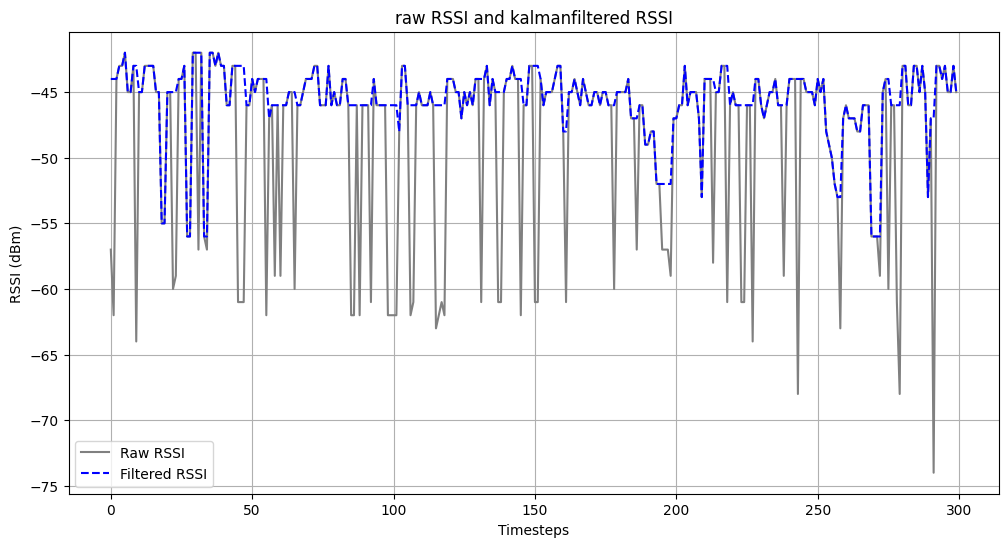

In [ ]:
# Sicherstellen, dass die Spalten korrekt benannt sind (falls notwendig)
df.columns = ['RSSI', 'Filtered', 'Distance']

# Reale Distanz als konstante festlegen
real_distance = 0.5

# Graphen erstellen
plt.figure(figsize=(12, 6))

# Plot für RSSI
plt.plot(df.index, df['RSSI'], label='Raw RSSI', linestyle='-', color='gray')

# Plot für gefilterten RSSI
plt.plot(df.index, df['Filtered'], label='Filtered RSSI', linestyle='--', color='blue')

plt.ylabel('RSSI (dBm)')
plt.xlabel('Timesteps')

# Zweite Y-Achse für die Distanz
# dist_ax = plt.gca().twinx()
# dist_ax.plot(df.index, df['Distance'], label='Distance', color='green', linestyle='--')

# Reale Distanz als konstante Linie hinzufügen
# dist_ax.axhline(y=real_distance, color='red', linestyle=':', label='Real Distance')

# Achsentitel und Beschriftungen setzen
# dist_ax.set_ylabel('Distance (m)')

plt.legend()
plt.grid()
plt.title('raw RSSI and kalmanfiltered RSSI')

plt.show()


# 2,5. Graph: RSSI und Filtered RSSI

<ipython-input-26-b0d2bc63f666>:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Filtered'] = df['RSSI'].where(df['RSSI'] < upper_limit).fillna(method='ffill').fillna(method='bfill')
<ipython-input-26-b0d2bc63f666>:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Filtered'] = df['RSSI'].where(df['RSSI'] > lower_limit).fillna(method='ffill').fillna(method='bfill')


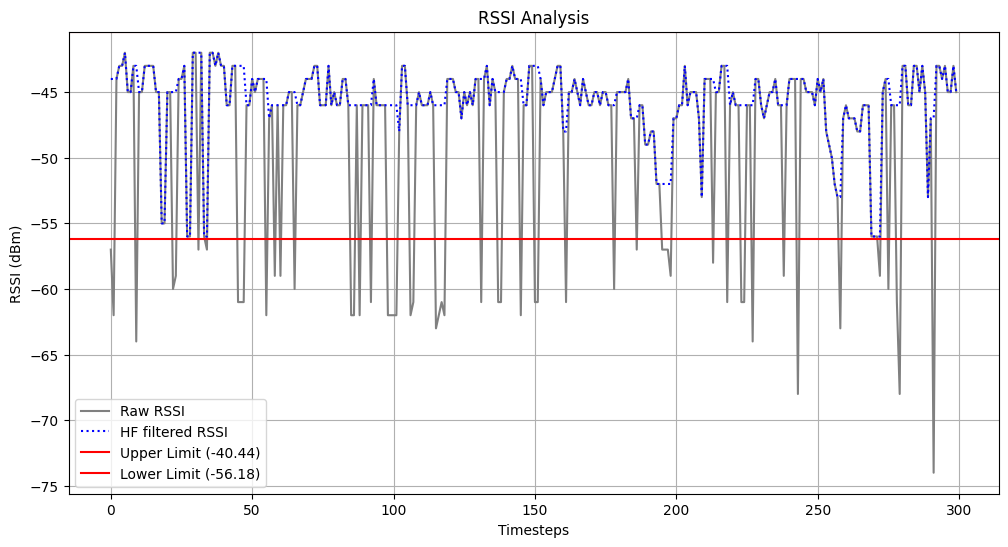

In [ ]:
# Sicherstellen, dass die Spalten korrekt benannt sind (falls notwendig)
df.columns = ['RSSI', 'Filtered', 'Distance']

# Berechnung des Mittelwerts und der Standardabweichung der RSSI-Werte
mean_rssi = df['RSSI'].mean()
std_rssi = df['RSSI'].std()

# Berechnung der Limits (Fluktuationsfilter)
upper_limit = mean_rssi + (1.2 * std_rssi)
lower_limit = mean_rssi - (1.2 * std_rssi)

# Filtern der RSSI-Werte, die das Upper Limit überschreiten
df['Filtered'] = df['RSSI'].where(df['RSSI'] < upper_limit).fillna(method='ffill').fillna(method='bfill')
df['Filtered'] = df['RSSI'].where(df['RSSI'] > lower_limit).fillna(method='ffill').fillna(method='bfill')

# Graphen erstellen
plt.figure(figsize=(12, 6))

# Plot für RSSI
plt.plot(df.index, df['RSSI'], label='Raw RSSI', linestyle='-', color='gray')

# Plot für gefilterten RSSI
plt.plot(df.index, df['Filtered'], label='HF filtered RSSI', linestyle=':', color='blue')

# Plot der Upper Limit und Lower Limit Linien
plt.axhline(y=upper_limit, color='red', linestyle='-', label=f'Upper Limit ({upper_limit:.2f})')
plt.axhline(y=lower_limit, color='red', linestyle='-', label=f'Lower Limit ({lower_limit:.2f})')

plt.ylabel('RSSI (dBm)')
plt.xlabel('Timesteps')

# Legenden anpassen
plt.legend()
plt.grid()
plt.title('RSSI Analysis')

plt.show()


# 3. Vergleich unterschiedliche RSSI Filter

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Datei hochladen
uploaded = files.upload()
file_name = next(iter(uploaded))

Saving messung2-2.xlsx to messung2-2 (1).xlsx


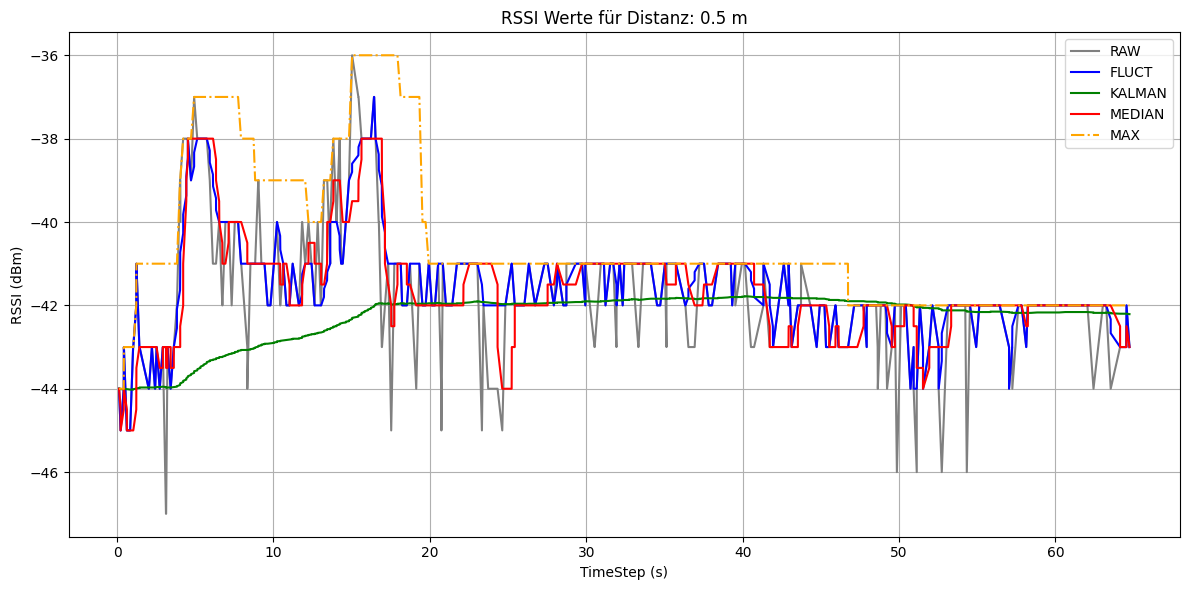

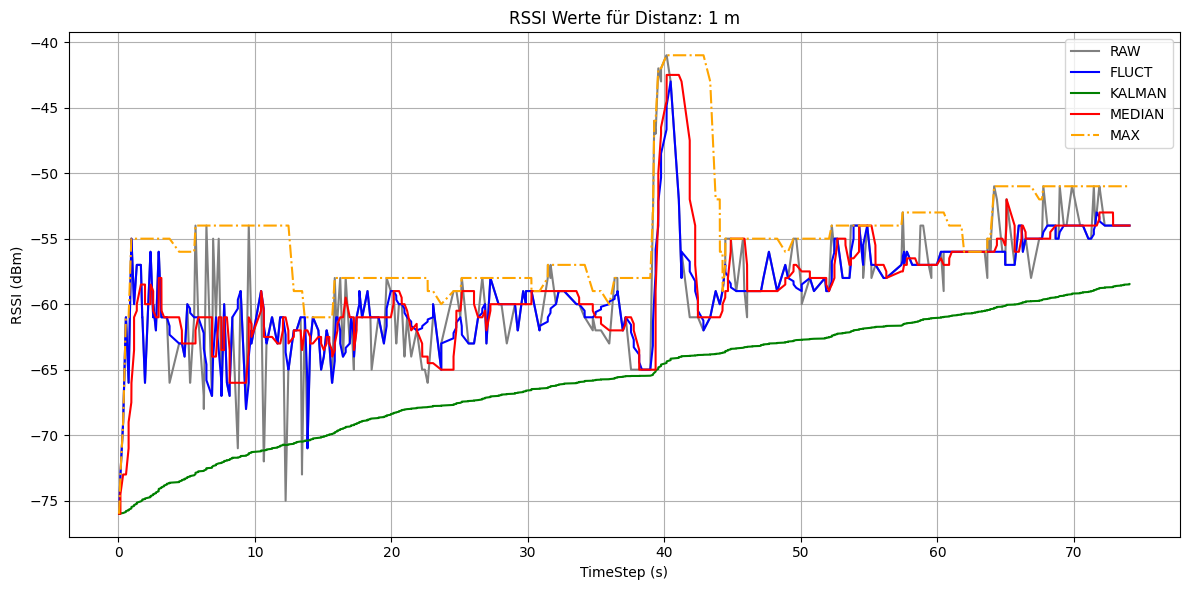

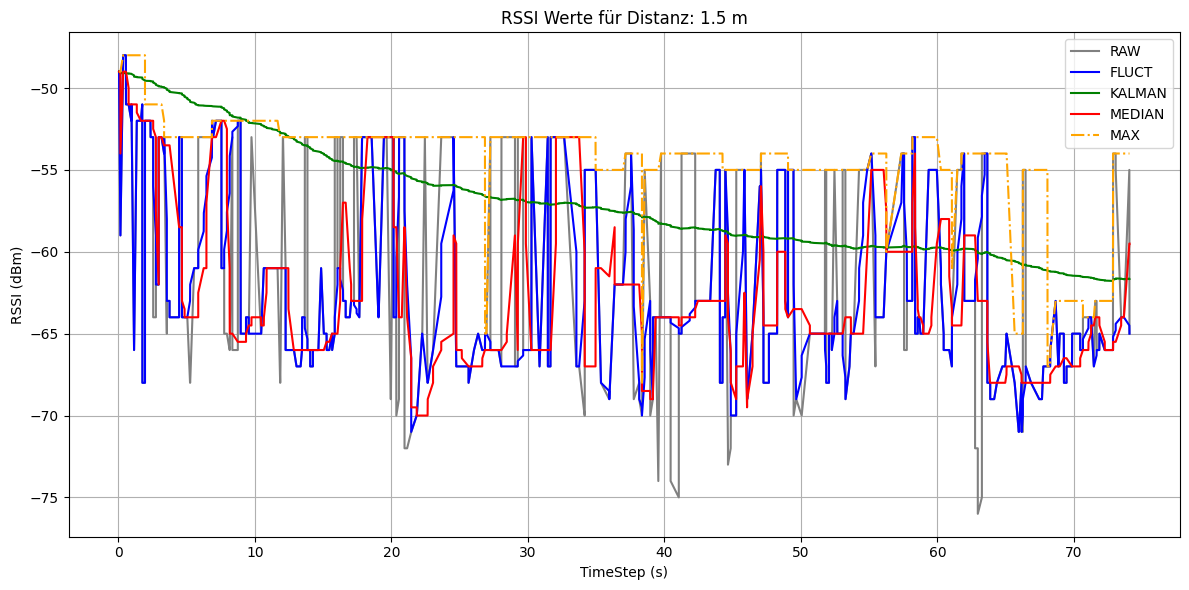

In [ ]:
# Excel-Datei einlesen
df = pd.read_excel(file_name, header=1)  # Die zweite Zeile enthält die Spaltenüberschriften
distances = pd.read_excel(file_name, header=None).iloc[0].dropna().unique()  # Die erste Zeile enthält die Distanzen

# Jede Distanz separat verarbeiten
num_filters = 5  # Anzahl der Filter (RAW, FLUCT, KALMAN, MEDIAN, MAX)
for i, dist in enumerate(distances):
    # Spalten für die aktuelle Distanz extrahieren
    start_col = i * (num_filters + 1)  # Startspalte für diese Distanz
    cols = df.columns[start_col : start_col + (num_filters + 1)]  # Zeitsäule + Filterspalten

    # Sub-DataFrame erstellen
    dist_df = df[cols].rename(columns={
        cols[0]: 'TimeStep',
        cols[1]: 'RAW',
        cols[2]: 'FLUCT',
        cols[3]: 'KALMAN',
        cols[4]: 'MEDIAN',
        cols[5]: 'MAX'
    })

    # NaN-Werte interpolieren
    dist_df = dist_df.interpolate()

    # Graphen erstellen
    plt.figure(figsize=(12, 6))
    plt.plot(dist_df['TimeStep'], dist_df['RAW'], label='RAW', color='gray', linestyle='-')
    plt.plot(dist_df['TimeStep'], dist_df['FLUCT'], label='FLUCT', color='blue', linestyle='-')
    plt.plot(dist_df['TimeStep'], dist_df['KALMAN'], label='KALMAN', color='green', linestyle='-')
    plt.plot(dist_df['TimeStep'], dist_df['MEDIAN'], label='MEDIAN', color='red', linestyle='-')
    plt.plot(dist_df['TimeStep'], dist_df['MAX'], label='MAX', color='orange', linestyle='-.')

    # Achsenbeschriftungen und Titel
    plt.ylabel('RSSI (dBm)')
    plt.xlabel('TimeStep (s)')
    plt.title(f'RSSI Werte für Distanz: {dist} m')
    plt.legend()
    plt.grid()
    plt.tight_layout()

    # Diagramm anzeigen
    plt.show()

2. distanz für jeden filter berechnen
3. mean squared error berechnen um zu sehen welcher filter die distanz am besten darstellt